In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score as sklearn_r2
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 11
plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

# Setup


In [86]:
def mse(y_true, y_pred):
    # Calculate Mean Squared Error
    # (num_samples,), (num_samples,) -> scalar
    return np.mean((y_true - y_pred) ** 2)


def r2(y_true, y_pred):
    # Calculate Coefficient of Determination
    # (num_samples,), (num_samples,) -> scalar
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1.0 - ss_res / ss_tot


def add_bias(X):
    # Prepend a column of ones for the bias term
    # (num_samples, model_dim) -> (num_samples, model_dim + 1)
    return np.hstack([np.ones((X.shape[0], 1)), X])


def plot_predictions(y_true, y_pred, title=""):
    # Create a scatter plot of true versus predicted values
    fig, ax = plt.subplots(1, 1, figsize=(6, 5))
    ax.scatter(y_true, y_pred, alpha=0.5, s=20)

    # Calculate limits for the perfect prediction line
    lims = [
        min(y_true.min(), y_pred.min()) - 1,
        max(y_true.max(), y_pred.max()) + 1,
    ]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title(title)
    ax.legend()
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()


def print_metrics(y_true, y_pred, label=""):
    # Print the evaluation metrics
    print(f"  {label:30s}  MSE={mse(y_true, y_pred):.6f}  R\u00b2={r2(y_true, y_pred):.6f}")


print("Utility functions defined.")

Utility functions defined.


In [87]:
num_samples = 300
model_dim = 5

# Define the ground truth weights and bias
# (model_dim,) -> (model_dim,)
true_weights = np.array([3.5, -2.1, 0.0, 1.7, 0.0])
true_bias = 4.0

# Generate random input features
# (num_samples, model_dim) -> (num_samples, model_dim)
X_all = np.random.randn(num_samples, model_dim)

# Generate target values with noise
# (num_samples, model_dim) @ (model_dim,) -> (num_samples,)
y_all = X_all @ true_weights + true_bias + 0.5 * np.random.randn(num_samples)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# Standardize features for regularized methods
scaler = StandardScaler()

# Scale training features
# (num_samples, model_dim) -> (num_samples, model_dim)
X_train_s = scaler.fit_transform(X_train)

# Scale testing features
# (num_samples, model_dim) -> (num_samples, model_dim)
X_test_s = scaler.transform(X_test)

print(f"Linear dataset: X_train {X_train_s.shape}, X_test {X_test_s.shape}")
print(f"True weights: {true_weights}, True bias: {true_bias}")

Linear dataset: X_train (240, 5), X_test (60, 5)
True weights: [ 3.5 -2.1  0.   1.7  0. ], True bias: 4.0


In [50]:
# === 1-D nonlinear dataset ===
np.random.seed(42)
num_samples_poly = 150

# (num_samples,)
X_poly_1d = np.sort(np.random.uniform(-3, 3, num_samples_poly))

# (num_samples,)
y_poly = 0.5 * X_poly_1d**3 - 2 * X_poly_1d**2 + X_poly_1d + 3 + 2.0 * np.random.randn(num_samples_poly)

X_poly_train, X_poly_test, y_poly_train, y_poly_test = train_test_split(
    X_poly_1d, y_poly, test_size=0.2, random_state=42
)

print(f"Polynomial dataset: train {X_poly_train.shape[0]}, test {X_poly_test.shape[0]}")

Polynomial dataset: train 120, test 30


In [51]:
# === Higher-dimensional dataset for final comparison ===
X_real, y_real = make_regression(
    n_samples=400, n_features=10, n_informative=5, noise=15.0, random_state=42
)
X_real_train, X_real_test, y_real_train, y_real_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

scaler_real = StandardScaler()
X_real_train_s = scaler_real.fit_transform(X_real_train)
X_real_test_s = scaler_real.transform(X_real_test)
print(f"Real-world dataset: train {X_real_train_s.shape}, test {X_real_test_s.shape}")

Real-world dataset: train (320, 10), test (80, 10)


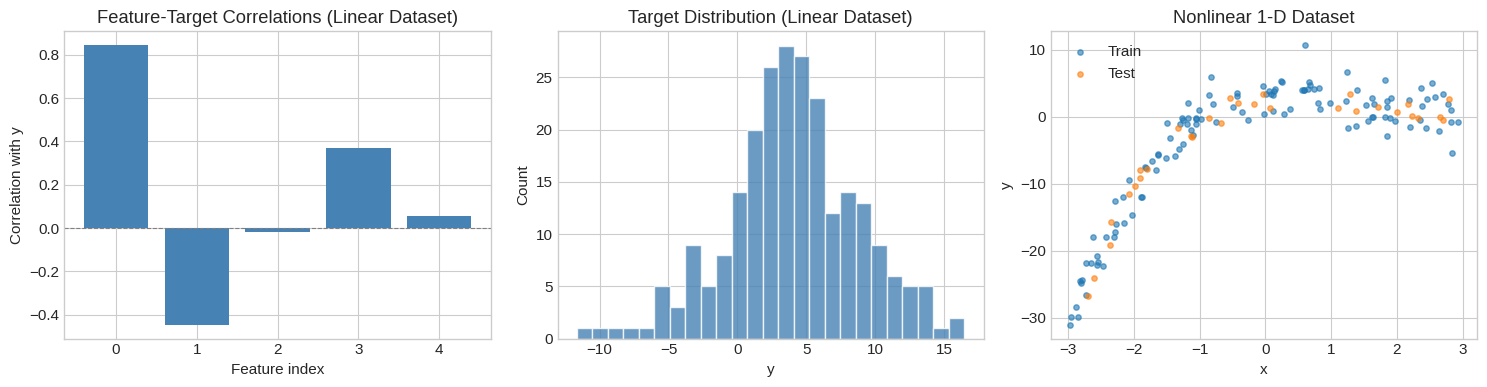

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Calculate feature correlation with target
# (model_dim,) -> scalar
correlations = [np.corrcoef(X_train_s[:, j], y_train)[0, 1] for j in range(model_dim)]
axes[0].bar(range(model_dim), correlations, color="steelblue")
axes[0].set_xlabel("Feature index")
axes[0].set_ylabel("Correlation with y")
axes[0].set_title("Feature-Target Correlations (Linear Dataset)")
axes[0].axhline(y=0, color="gray", linestyle="--", linewidth=0.8)

# Plot target distribution
axes[1].hist(y_train, bins=25, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].set_xlabel("y")
axes[1].set_ylabel("Count")
axes[1].set_title("Target Distribution (Linear Dataset)")

# Plot 1-D nonlinear data
axes[2].scatter(X_poly_train, y_poly_train, s=15, alpha=0.6, label="Train")
axes[2].scatter(X_poly_test, y_poly_test, s=15, alpha=0.6, label="Test")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_title("Nonlinear 1-D Dataset")
axes[2].legend()

plt.tight_layout()
plt.show()

---
# 1) Linear Regression

Linear regression is the foundational supervised learning algorithm. It models the target as a linear combination of input features:

$$
\hat{y} = \mathbf{X}\mathbf{w} + b
$$

**When to use:** When the relationship between features and target is approximately linear, or as a baseline before trying more complex models.

**Sample Input/Output:**

| $x_1$ | $x_2$ | $y$ |
|-------|-------|------|
| 1.0 | 2.0 | 7.5 |
| 2.0 | 1.0 | 5.5 |
| 3.0 | 3.0 | 13.0 |

If the true relationship is $y = 2x_1 + 1.5x_2 + 1$, linear regression recovers these coefficients from data.

**Two solution strategies:**
1. **Closed-form (Normal Equation):** Exact analytical solution in one step. $O(np^2 + p^3)$ complexity.
2. **Gradient Descent:** Iterative optimization. $O(npT)$ where $T$ is the number of iterations. Preferred when $p$ is very large.

## 1.1 Closed-Form Solution

We seek $\mathbf{w}^*$ that minimizes the sum of squared residuals. Absorbing the bias into $\mathbf{w}$ by prepending a column of ones to $\mathbf{X}$:

$$J(\mathbf{w}) = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 = (\mathbf{X}\mathbf{w} - \mathbf{y})^\top(\mathbf{X}\mathbf{w} - \mathbf{y})$$

**Expanding:**

$$J(\mathbf{w}) = \mathbf{w}^\top\mathbf{X}^\top\mathbf{X}\mathbf{w} - 2\mathbf{w}^\top\mathbf{X}^\top\mathbf{y} + \mathbf{y}^\top\mathbf{y}$$

**Taking the gradient** (using matrix calculus identities $\nabla_\mathbf{w}(\mathbf{w}^\top\mathbf{A}\mathbf{w}) = 2\mathbf{A}\mathbf{w}$ for symmetric $\mathbf{A}$, and $\nabla_\mathbf{w}(\mathbf{b}^\top\mathbf{w}) = \mathbf{b}$):

$$\nabla_\mathbf{w} J = 2\mathbf{X}^\top\mathbf{X}\mathbf{w} - 2\mathbf{X}^\top\mathbf{y}$$

**Setting to zero:**

$$\mathbf{X}^\top\mathbf{X}\mathbf{w}^* = \mathbf{X}^\top\mathbf{y}$$

$$\boxed{\mathbf{w}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}}$$

> **Note on existence:** The solution is unique iff $\mathbf{X}^\top\mathbf{X}$ is invertible (i.e., $\mathbf{X}$ has full column rank). When $n < p$ or features are collinear, $\mathbf{X}^\top\mathbf{X}$ is singular — motivating regularization (Section 2).

> **Geometric interpretation:** $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}^*$ is the orthogonal projection of $\mathbf{y}$ onto the column space of $\mathbf{X}$. The projection matrix is $\mathbf{H} = \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$, known as the *hat matrix*.

In [79]:
class LinearRegressionOLS:
    def fit(self, X, Y):

        # Ensure we are working with 1D arrays
        # (num_samples, 1) -> (num_samples,)
        X = X.flatten()
        # (num_samples, 1) -> (num_samples,)
        Y = Y.flatten()

        x_mean = np.mean(X)
        y_mean = np.mean(Y)

        # Calculate explicit variance and covariance
        # (num_samples,) -> scalar
        numerator = np.sum((X - x_mean) * (Y - y_mean))
        # (num_samples,) -> scalar
        denominator = np.sum((X - x_mean) ** 2)

        self.w = numerator / denominator
        self.b = y_mean - (self.w * x_mean)

        # Store as arrays to maintain compatibility
        self.weights = np.array([self.w])
        self.bias = self.b
        return self

    def predict(self, X):
        # Calculate predictions
        # (num_samples,) -> (num_samples,)
        return X.flatten() * self.w + self.b


# Extract first feature for 1D OLS
X_train_1d = X_train_s[:, 0]
X_test_1d = X_test_s[:, 0]

ols = LinearRegressionOLS().fit(X_train_1d, y_train)
y_pred_ols_train = ols.predict(X_train_1d)
y_pred_ols_test = ols.predict(X_test_1d)

print("Explicit 1D OLS Results (Feature 0 only):")
print_metrics(y_train, y_pred_ols_train, "Train")
print_metrics(y_test, y_pred_ols_test, "Test")
print(f"\n  Learned weight (m): {ols.weights[0]:.4f}")
print(f"  Learned bias (c):   {ols.bias:.4f}")
print(f"  True weight[0]:     {true_weights[0]}")
print(f"  True bias:          {true_bias}")

Explicit 1D OLS Results (Feature 0 only):
  Train                           MSE=8.471939  R²=0.582002
  Test                            MSE=5.372463  R²=0.619565

  Learned weight (m): 3.4345
  Learned bias (c):   3.9942
  True weight[0]:     3.5
  True bias:          4.0


## 1.2 Gradient Descent Solution

Instead of solving the normal equations directly, we iteratively update $\mathbf{w}$ in the direction of steepest descent:

$$\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \alpha \nabla_\mathbf{w} J(\mathbf{w}^{(t)})$$

where $\alpha > 0$ is the **learning rate**. The gradient of the MSE cost is:

$$\nabla_\mathbf{w} J = \frac{2}{n}\mathbf{X}^\top(\mathbf{X}\mathbf{w} - \mathbf{y})$$

**Convergence:** For convex quadratic objectives, gradient descent converges at rate $O\left(\left(\frac{\kappa - 1}{\kappa + 1}\right)^t\right)$ where $\kappa = \lambda_{\max} / \lambda_{\min}$ is the condition number of $\mathbf{X}^\top\mathbf{X}$. Feature standardization reduces $\kappa$, improving convergence.

**Learning rate selection:** Must satisfy $\alpha < \frac{2}{\lambda_{\max}(\mathbf{X}^\top\mathbf{X}/n)}$ for convergence. In practice, values like $0.01$ or $0.001$ work well with standardized data.

In [80]:
class LinearRegressionGD:
    def __init__(self, lr=0.01, max_iter=1000):
        self.lr = lr
        self.max_iter = max_iter

    def fit(self, X, Y):
        self.num_samples, self.model_dim = X.shape
        self.W = np.zeros(self.model_dim)
        self.b = 0
        self.loss_history = []

        for _ in range(self.max_iter):
            # Calculate current predicted value of Y
            # (num_samples, model_dim) -> (num_samples,)
            Y_pred = X.dot(self.W) + self.b

            # Calculate weight gradients
            # (model_dim, num_samples) -> (model_dim,)
            dW = (-2 / self.num_samples) * X.T.dot(Y - Y_pred)

            # Calculate bias gradient
            # (num_samples,) -> scalar
            db = (-2 / self.num_samples) * np.sum(Y - Y_pred)

            # Update weights and bias
            self.W -= self.lr * dW
            self.b -= self.lr * db

            # Track loss
            loss = np.mean((Y_pred - Y) ** 2)
            self.loss_history.append(loss)

        self.weights = self.W
        self.bias = self.b
        return self

    def predict(self, X):
        # Calculate predictions
        # (num_samples, model_dim) -> (num_samples,)
        return X.dot(self.W) + self.b


gd = LinearRegressionGD(lr=0.05, max_iter=2000).fit(X_train_s, y_train)
y_pred_gd_train = gd.predict(X_train_s)
y_pred_gd_test = gd.predict(X_test_s)

print("GD Results:")
print_metrics(y_train, y_pred_gd_train, "Train")
print_metrics(y_test, y_pred_gd_test, "Test")
print(f"\n  Learned weights: {gd.weights.round(4)}")

GD Results:
  Train                           MSE=0.233542  R²=0.988477
  Test                            MSE=0.262841  R²=0.981388

  Learned weights: [ 3.2609 -2.3083  0.0153  1.7341  0.0225]


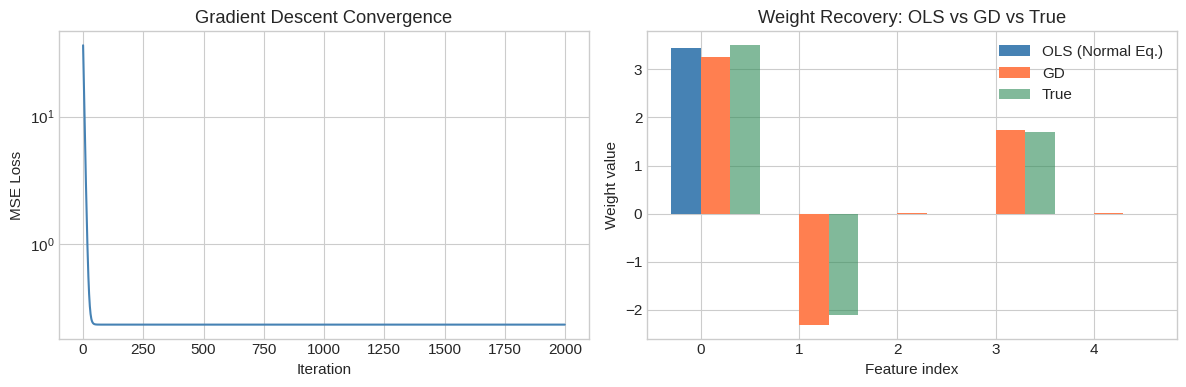

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot convergence curve for Gradient Descent
axes[0].plot(gd.loss_history, color="steelblue", linewidth=1.5)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Gradient Descent Convergence")
axes[0].set_yscale("log")

# Compare weights: OLS vs GD vs True
x_pos = np.arange(model_dim)
width = 0.3

# Pad OLS weights with zeros for missing dimensions to avoid plotting errors
ols_plot_weights = np.zeros(model_dim)
ols_plot_weights[0] = ols.weights[0]

axes[1].bar(x_pos - width / 2, ols_plot_weights, width, label="OLS (Normal Eq.)", color="steelblue")
axes[1].bar(x_pos + width / 2, gd.weights, width, label="GD", color="coral")
axes[1].bar(x_pos + 3 * width / 2, true_weights, width, label="True", color="seagreen", alpha=0.6)
axes[1].set_xlabel("Feature index")
axes[1].set_ylabel("Weight value")
axes[1].set_title("Weight Recovery: OLS vs GD vs True")
axes[1].legend()

plt.tight_layout()
plt.show()

## 1.3 Comparison with sklearn

We validate our from-scratch implementations against `sklearn.linear_model.LinearRegression`.

Test Set Comparison:
  OLS (from scratch)              MSE=0.262841  R²=0.981388
  GD  (from scratch)              MSE=0.262841  R²=0.981388
  sklearn LinearRegression        MSE=0.262841  R²=0.981388


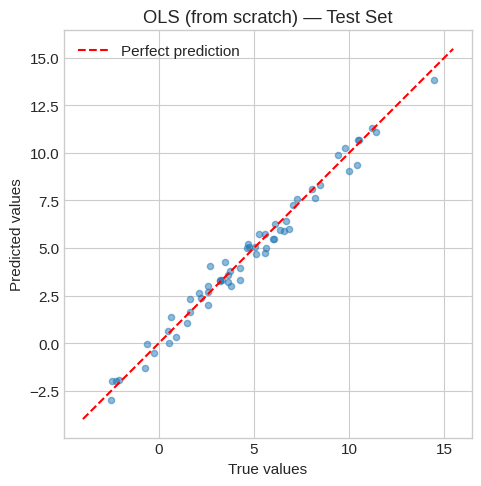

In [56]:
sk_lr = LinearRegression().fit(X_train_s, y_train)
y_pred_sk_test = sk_lr.predict(X_test_s)

print("Test Set Comparison:")
print_metrics(y_test, y_pred_ols_test, "OLS (from scratch)")
print_metrics(y_test, y_pred_gd_test, "GD  (from scratch)")
print_metrics(y_test, y_pred_sk_test, "sklearn LinearRegression")

plot_predictions(y_test, y_pred_ols_test, "OLS (from scratch) — Test Set")

---
# 2) Ridge Regression (L2 Regularization)

When features are correlated or $p \approx n$, OLS yields unstable, high-variance estimates. Ridge regression adds a penalty on the magnitude of weights, shrinking them toward zero and stabilizing the solution.

**When to use:**
- Multicollinearity among features
- Overfitting with OLS (high train performance, poor test performance)
- When all features are believed to be relevant (Ridge does not set any weight exactly to zero)

**Sample scenario:** In genomics, $p \gg n$ makes $\mathbf{X}^\top\mathbf{X}$ singular. Ridge adds $\lambda\mathbf{I}$ to make it invertible.

**Objective:**

$$J_{\text{ridge}}(\mathbf{w}) = \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \lambda\|\mathbf{w}\|_2^2$$

where $\lambda \geq 0$ controls regularization strength.

In [82]:
class RidgeRegressor:
    def __init__(self, lam=1.0, lr=0.01, max_iter=1000):
        self.lam = lam
        self.lr = lr
        self.max_iter = max_iter

    def fit(self, X, Y):
        self.num_samples, self.model_dim = X.shape
        self.W = np.zeros(self.model_dim)
        self.b = 0
        self.loss_history = []

        for _ in range(self.max_iter):
            # Calculate current predictions
            # (num_samples, model_dim) -> (num_samples,)
            Y_pred = X.dot(self.W) + self.b

            # Calculate weight gradients with L2 penalty
            # (model_dim, num_samples) -> (model_dim,)
            dW = (
                # standard gradient for MSE
                (-2 / self.num_samples) * X.T.dot(Y - Y_pred) +
                # L2 penalty for gradient
                 (2 * self.lam * self.W)
            )

            # Calculate bias gradient
            # (num_samples,) -> scalar
            db = (-2 / self.num_samples) * np.sum(Y - Y_pred)

            # Update weights and bias
            self.W -= self.lr * dW
            self.b -= self.lr * db

            # Track loss
            loss = np.mean((Y_pred - Y) ** 2) + self.lam * np.sum(self.W ** 2)
            self.loss_history.append(loss)

        self.weights = self.W
        self.bias = self.b
        return self

    def predict(self, X):
        # Calculate predictions
        # (num_samples, model_dim) -> (num_samples,)
        return X.dot(self.W) + self.b


ridge = RidgeRegressor(lam=0.1, lr=0.05, max_iter=2000).fit(X_train_s, y_train)
y_pred_ridge_test = ridge.predict(X_test_s)

print("Ridge (from scratch, GD, lambda=0.1):")
print_metrics(y_test, y_pred_ridge_test, "Test")
print(f"  Weights: {ridge.weights.round(4)}")

Ridge (from scratch, GD, lambda=0.1):
  Test                            MSE=0.393981  R²=0.972101
  Weights: [ 2.9753 -2.0984  0.0505  1.5927 -0.0039]


---
# 3) Lasso Regression (L1 Regularization)

While Ridge shrinks all weights toward zero, Lasso can drive weights **exactly to zero**, performing automatic feature selection. This is invaluable when you suspect many features are irrelevant.

**When to use:**
- High-dimensional data where only a few features matter
- When you need an interpretable, sparse model
- Feature selection as part of the modeling pipeline

**Objective:**

$$J_{\text{lasso}}(\mathbf{w}) = \frac{1}{2n}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \lambda\|\mathbf{w}\|_1$$

The $\ell_1$ norm $\|\mathbf{w}\|_1 = \sum_j |w_j|$ is **not differentiable** at $w_j = 0$, precluding a closed-form solution.

In [88]:
class LassoRegressor:
    def __init__(self, lam=0.1, lr=0.01, max_iter=1000):
        self.lam = lam
        self.lr = lr
        self.max_iter = max_iter

    def fit(self, X, Y):
        self.num_samples, self.model_dim = X.shape
        self.W = np.zeros(self.model_dim)
        self.b = 0
        self.loss_history = []

        for _ in range(self.max_iter):
            # Calculate current predictions
            # (num_samples, model_dim) -> (num_samples,)
            Y_pred = X.dot(self.W) + self.b

            # Calculate standard MSE gradients
            # (model_dim, num_samples) -> (model_dim,)
            dW = (-2 / self.num_samples) * X.T.dot(Y - Y_pred)
            db = (-2 / self.num_samples) * np.sum(Y - Y_pred)

            # Update weights using standard MSE gradient
            self.W -= self.lr * dW
            self.b -= self.lr * db

            # Apply L1 Penalty Soft Thresholding
            # penalty is absolute value, so + lambda
            shrinkage = self.lam * self.lr

            # set features to 0 if weight too small
            for j in range(self.model_dim):
                if self.W[j] > shrinkage:
                    self.W[j] -= shrinkage
                elif self.W[j] < -shrinkage:
                    self.W[j] += shrinkage
                else:
                    self.W[j] = 0.0

            # Track loss
            loss = np.mean((Y_pred - Y)**2) + self.lam * np.sum(np.abs(self.W))
            self.loss_history.append(loss)

        self.weights = self.W
        self.bias = self.b
        return self

    def predict(self, X):
        # Calculate predictions
        # (num_samples, model_dim) -> (num_samples,)
        return X.dot(self.W) + self.b


lasso = LassoRegressor(lam=0.05, lr=0.05, max_iter=2000).fit(X_train_s, y_train)
y_pred_lasso_test = lasso.predict(X_test_s)

print("Lasso (from scratch, lambda=0.05):")
print_metrics(y_test, y_pred_lasso_test, "Test")
print(f"  Weights: {lasso.weights.round(4)}")
print(f"  Non-zero weights: {np.sum(np.abs(lasso.weights) > 1e-6)} / {model_dim}")

Lasso (from scratch, lambda=0.05):
  Test                            MSE=0.229242  R²=0.987307
  Weights: [ 3.7645 -2.0317  0.      1.625   0.    ]
  Non-zero weights: 3 / 5


---
# 4) ElasticNet Regression

**Intuition:** ElasticNet combines the strengths of Ridge and Lasso:
- **From Lasso:** Sparsity / feature selection via $\ell_1$ penalty
- **From Ridge:** Stability when features are correlated via $\ell_2$ penalty

**When to use:**
- Correlated feature groups where Lasso arbitrarily selects one and ignores others (the **grouping effect** problem)
- When you want both sparsity and regularization stability

**Objective:**

$$J_{\text{EN}}(\mathbf{w}) = \frac{1}{2n}\|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2 + \alpha \cdot r \cdot \|\mathbf{w}\|_1 + \frac{\alpha(1 - r)}{2}\|\mathbf{w}\|_2^2$$

where:
- $\alpha \geq 0$: overall regularization strength
- $r \in [0, 1]$: L1 ratio ($r=1$ is Lasso, $r=0$ is Ridge)

In [89]:
class ElasticNetRegressor:
    def __init__(self, alpha=0.1, l1_ratio=0.5, lr=0.01, max_iter=1000):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.lr = lr
        self.max_iter = max_iter

    def fit(self, X, Y):
        self.num_samples, self.model_dim = X.shape
        self.W = np.zeros(self.model_dim)
        self.b = 0
        self.loss_history = []

        l1_penalty = self.alpha * self.l1_ratio
        l2_penalty = self.alpha * (1.0 - self.l1_ratio)

        for _ in range(self.max_iter):
            # Calculate current predictions
            # (num_samples, model_dim) -> (num_samples,)
            Y_pred = X.dot(self.W) + self.b

            # Calculate weight gradients with L2 penalty
            # (model_dim, num_samples) -> (model_dim,)
            dW = (-2 / self.num_samples) * X.T.dot(Y - Y_pred) + (2 * l2_penalty * self.W)

            # Calculate bias gradient
            # (num_samples,) -> scalar
            db = (-2 / self.num_samples) * np.sum(Y - Y_pred)

            # Update weights and bias
            self.W -= self.lr * dW
            self.b -= self.lr * db

            # Apply L1 penalty soft thresholding
            shrinkage = l1_penalty * self.lr
            for j in range(self.model_dim):
                if self.W[j] > shrinkage:
                    self.W[j] -= shrinkage
                elif self.W[j] < -shrinkage:
                    self.W[j] += shrinkage
                else:
                    self.W[j] = 0.0

            # Track loss
            loss = (
                np.mean((Y_pred - Y) ** 2)
                + l1_penalty * np.sum(np.abs(self.W))
                + l2_penalty * np.sum(self.W ** 2)
            )
            self.loss_history.append(loss)

        self.weights = self.W
        self.bias = self.b
        return self

    def predict(self, X):
        # Calculate predictions
        # (num_samples, model_dim) -> (num_samples,)
        return X.dot(self.W) + self.b


en = ElasticNetRegressor(alpha=0.1, l1_ratio=0.5, lr=0.05, max_iter=2000).fit(X_train_s, y_train)
y_pred_en_test = en.predict(X_test_s)

print("ElasticNet (from scratch, alpha=0.1, l1_ratio=0.5):")
print_metrics(y_test, y_pred_en_test, "Test")
print(f"  Weights: {en.weights.round(4)}")
print(f"  Non-zero: {np.sum(np.abs(en.weights) > 1e-6)} / {model_dim}")

ElasticNet (from scratch, alpha=0.1, l1_ratio=0.5):
  Test                            MSE=0.258955  R²=0.985662
  Weights: [ 3.5955e+00 -1.9380e+00  0.0000e+00  1.5529e+00  2.2000e-03]
  Non-zero: 4 / 5


---
# 5) Polynomial Regression

Real-world relationships are rarely perfectly linear. Polynomial regression captures nonlinear patterns by transforming the input features into polynomial terms, then applying linear regression in this expanded feature space.

**When to use:**
- Clearly nonlinear relationship in the data
- Moderate number of features (polynomial expansion is combinatorial in the number of features)
- When you want an interpretable parametric model that captures curvature

**Key idea:** We don't change the algorithm — we change the **representation**. Given a scalar input $x$, we construct:

$$\phi(x) = [1,\; x,\; x^2,\; \ldots,\; x^d]$$

Then fit a linear model: $\hat{y} = \phi(x)^\top \mathbf{w}$, which is a degree-$d$ polynomial in $x$.

In [84]:
class PolynomialRegressor:
    def __init__(self, degree=2, lr=0.01, max_iter=1000):
        self.degree = degree
        self.lr = lr
        self.max_iter = max_iter
        self.mean = None
        self.std = None

    def transform(self, X):
        # Expand scalar input to polynomial features
        # (num_samples,) -> (num_samples, model_dim)
        X = X.flatten()
        X_transform = np.column_stack([X ** k for k in range(1, self.degree + 1)])
        return X_transform

    def normalize_fit(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        self.std[self.std == 0] = 1e-8

        # Normalize features
        # (num_samples, model_dim) -> (num_samples, model_dim)
        return (X - self.mean) / self.std

    def normalize_transform(self, X):
        # Normalize features
        # (num_samples, model_dim) -> (num_samples, model_dim)
        return (X - self.mean) / self.std

    def fit(self, X, Y):
        self.num_samples = len(X)
        self.model_dim = self.degree
        self.W = np.zeros(self.model_dim)
        self.b = 0

        X_poly = self.transform(X)
        X_norm = self.normalize_fit(X_poly)

        for _ in range(self.max_iter):
            # Calculate predictions
            # (num_samples, model_dim) -> (num_samples,)
            Y_pred = X_norm.dot(self.W) + self.b

            # Calculate weight gradients
            # (model_dim, num_samples) -> (model_dim,)
            dW = (-2 / self.num_samples) * X_norm.T.dot(Y - Y_pred)

            # Calculate bias gradient
            # (num_samples,) -> scalar
            db = (-2 / self.num_samples) * np.sum(Y - Y_pred)

            # Update weights and bias
            self.W -= self.lr * dW
            self.b -= self.lr * db

        self.weights = self.W
        self.bias = self.b
        return self

    def predict(self, X):
        X_poly = self.transform(X)
        X_norm = self.normalize_transform(X_poly)

        # Calculate predictions
        # (num_samples, model_dim) -> (num_samples,)
        return X_norm.dot(self.W) + self.b


# Fit polynomials of different degrees
degrees = [1, 3, 5, 9, 15]
poly_models = {}

for d in degrees:
    model = PolynomialRegressor(degree=d, lr=0.1, max_iter=5000).fit(X_poly_train, y_poly_train)
    poly_models[d] = model
    y_pred_train = model.predict(X_poly_train)
    y_pred_test = model.predict(X_poly_test)
    print(
        f"  Degree {d:2d}: Train MSE={mse(y_poly_train, y_pred_train):.4f}, "
        f"Test MSE={mse(y_poly_test, y_pred_test):.4f}"
    )

  Degree  1: Train MSE=43.3697, Test MSE=32.1727
  Degree  3: Train MSE=4.7516, Test MSE=1.9291
  Degree  5: Train MSE=4.6859, Test MSE=2.1031
  Degree  9: Train MSE=4.5618, Test MSE=2.2800
  Degree 15: Train MSE=4.4591, Test MSE=2.4826


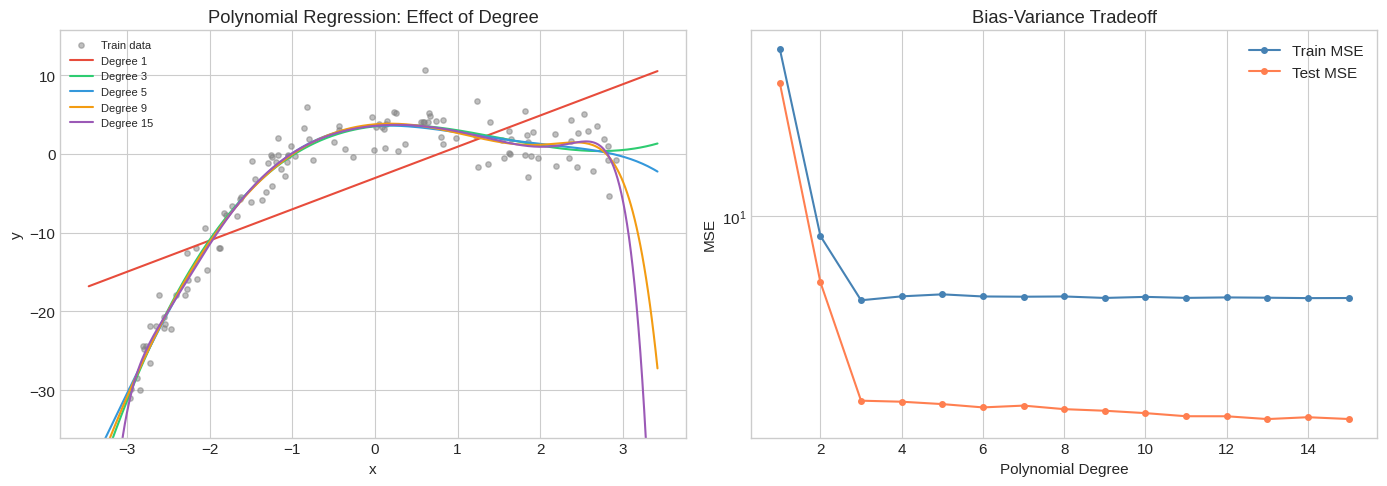

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Polynomial fits across degrees
x_grid = np.linspace(X_poly_1d.min() - 0.5, X_poly_1d.max() + 0.5, 300)

axes[0].scatter(X_poly_train, y_poly_train, s=15, alpha=0.5, color="gray", label="Train data")
colors = ["#e74c3c", "#2ecc71", "#3498db", "#f39c12", "#9b59b6"]
for (d, model), color in zip(poly_models.items(), colors):
    y_grid = model.predict(x_grid)
    axes[0].plot(x_grid, y_grid, label=f"Degree {d}", color=color, linewidth=1.5)
axes[0].set_ylim(y_poly.min() - 5, y_poly.max() + 5)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Polynomial Regression: Effect of Degree")
axes[0].legend(fontsize=8)

# Bias-variance tradeoff (train vs test MSE)
all_degrees = range(1, 16)
train_mses = []
test_mses = []
for d in all_degrees:
    model = PolynomialRegressor(degree=d).fit(X_poly_train, y_poly_train)
    train_mses.append(mse(y_poly_train, model.predict(X_poly_train)))
    test_mses.append(mse(y_poly_test, model.predict(X_poly_test)))

axes[1].plot(list(all_degrees), train_mses, "o-", label="Train MSE", color="steelblue", markersize=4)
axes[1].plot(list(all_degrees), test_mses, "o-", label="Test MSE", color="coral", markersize=4)
axes[1].set_xlabel("Polynomial Degree")
axes[1].set_ylabel("MSE")
axes[1].set_title("Bias-Variance Tradeoff")
axes[1].legend()
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

High-degree polynomials overfit severely. Combining polynomial features with Ridge regularization tames the oscillations while retaining the model's ability to capture nonlinearity.

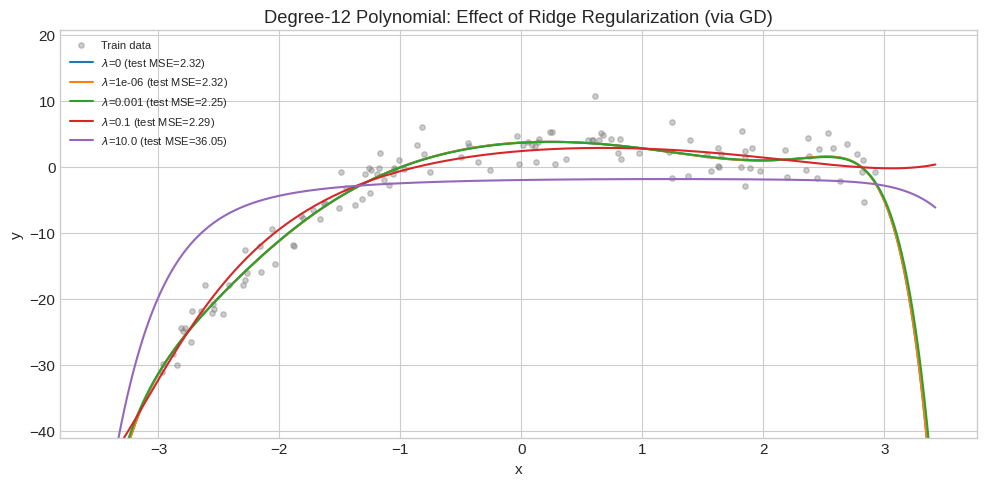

In [85]:
class PolynomialRidgeRegressor:
    def __init__(self, degree=9, lam=0.01, lr=0.01, max_iter=10000):
        self.degree = degree
        self.lam = lam
        self.lr = lr
        self.max_iter = max_iter
        self.mean = None
        self.std = None

    def fit(self, X, Y):
        # Expand scalar input to polynomial features
        # (num_samples,) -> (num_samples, model_dim)
        Phi = np.column_stack([X ** k for k in range(1, self.degree + 1)])

        self.num_samples, self.model_dim = Phi.shape
        self.W = np.zeros(self.model_dim)
        self.b = 0

        self.mean = np.mean(Phi, axis=0)
        self.std = np.std(Phi, axis=0)
        self.std[self.std == 0] = 1e-8

        # Normalize features
        # (num_samples, model_dim) -> (num_samples, model_dim)
        Phi_norm = (Phi - self.mean) / self.std

        for _ in range(self.max_iter):
            # Calculate predictions
            # (num_samples, model_dim) -> (num_samples,)
            Y_pred = Phi_norm.dot(self.W) + self.b

            # Calculate weight gradients with Ridge penalty
            # (model_dim, num_samples) -> (model_dim,)
            dW = (-2 / self.num_samples) * Phi_norm.T.dot(Y - Y_pred) + (2 * self.lam * self.W)

            # Calculate bias gradient
            # (num_samples,) -> scalar
            db = (-2 / self.num_samples) * np.sum(Y - Y_pred)

            # Update weights and bias
            self.W -= self.lr * dW
            self.b -= self.lr * db

        return self

    def predict(self, X):
        # Expand scalar input to polynomial features
        # (num_samples,) -> (num_samples, model_dim)
        Phi = np.column_stack([X ** k for k in range(1, self.degree + 1)])

        # Normalize features
        # (num_samples, model_dim) -> (num_samples, model_dim)
        Phi_norm = (Phi - self.mean) / self.std

        # Calculate predictions
        # (num_samples, model_dim) -> (num_samples,)
        return Phi_norm.dot(self.W) + self.b


degree = 12
lambdas_poly = [0, 1e-6, 1e-3, 0.1, 10.0]
x_grid = np.linspace(X_poly_1d.min() - 0.5, X_poly_1d.max() + 0.5, 300)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.scatter(X_poly_train, y_poly_train, s=15, alpha=0.4, color="gray", label="Train data")

for lam in lambdas_poly:
    model = PolynomialRidgeRegressor(degree=degree, lam=lam, lr=0.01, max_iter=10000).fit(
        X_poly_train, y_poly_train
    )
    y_grid = model.predict(x_grid)
    test_err = mse(y_poly_test, model.predict(X_poly_test))
    ax.plot(x_grid, y_grid, label=f"$\\lambda$={lam} (test MSE={test_err:.2f})", linewidth=1.5)

ax.set_ylim(y_poly.min() - 10, y_poly.max() + 10)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Degree-{degree} Polynomial: Effect of Ridge Regularization (via GD)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
# 6) Support Vector Regression (SVR)

SVR adapts the ideas of Support Vector Machines to regression. Instead of minimizing squared error, SVR defines an **$\varepsilon$-insensitive tube** around the predictions: errors within $\varepsilon$ incur zero loss, while errors beyond $\varepsilon$ are penalized linearly. This makes SVR robust to small noise and focused on the structure of the data.

**When to use:**
- When robustness to outliers is important
- Nonlinear relationships (via kernel trick)
- Moderate-sized datasets (SVR scales poorly with $n$ due to the quadratic programming solver)

**Key hyperparameters:**
- $\varepsilon$: Width of the insensitive tube
- $C$: Regularization parameter (inverse of $\lambda$). Larger $C$ allows fewer violations.
- Kernel choice: linear, RBF, polynomial

In [63]:
# SVR on the 1-D nonlinear dataset using sklearn
# Reshape for sklearn: (num_samples,) -> (num_samples, 1)
X_poly_train_2d = X_poly_train.reshape(-1, 1)
X_poly_test_2d = X_poly_test.reshape(-1, 1)

kernels = ["linear", "rbf", "poly"]
svr_models = {}

for kernel in kernels:
    svr = SVR(kernel=kernel, C=100.0, epsilon=0.5, gamma="scale", degree=3)
    svr.fit(X_poly_train_2d, y_poly_train)
    svr_models[kernel] = svr
    y_pred_test = svr.predict(X_poly_test_2d)
    print(f"  SVR ({kernel:6s}): Test MSE={mse(y_poly_test, y_pred_test):.4f}, "
          f"R²={r2(y_poly_test, y_pred_test):.4f}, "
          f"Support vectors: {svr.n_support_}")

  SVR (linear): Test MSE=34.8007, R²=0.4699, Support vectors: [114]
  SVR (rbf   ): Test MSE=1.9760, R²=0.9699, Support vectors: [101]
  SVR (poly  ): Test MSE=43.3160, R²=0.3401, Support vectors: [112]


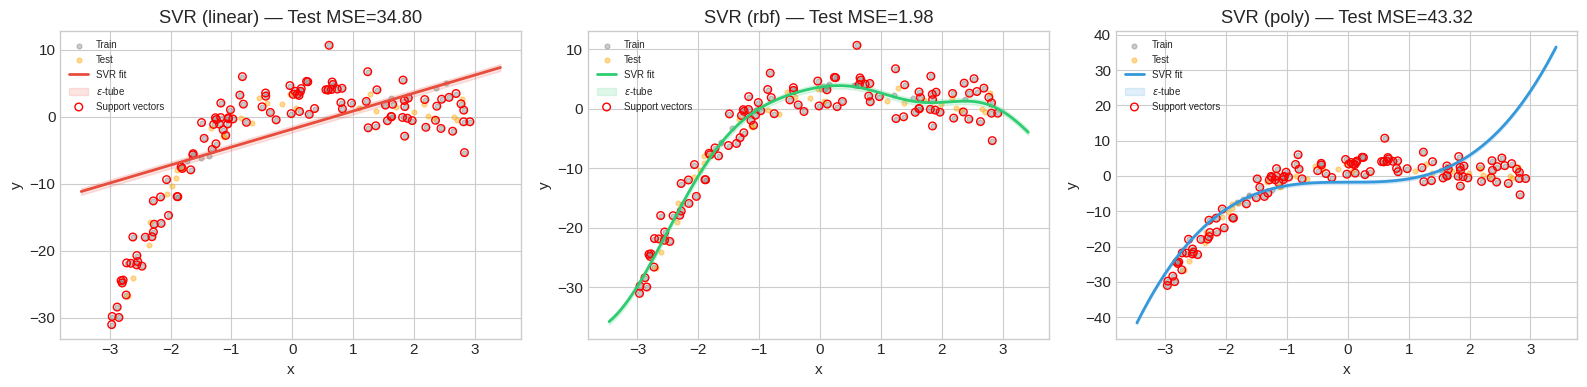

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
x_grid = np.linspace(X_poly_1d.min() - 0.5, X_poly_1d.max() + 0.5, 300).reshape(-1, 1)
colors = {"linear": "#e74c3c", "rbf": "#2ecc71", "poly": "#3498db"}

for ax, kernel in zip(axes, kernels):
    svr = svr_models[kernel]
    y_grid = svr.predict(x_grid)

    ax.scatter(X_poly_train, y_poly_train, s=12, alpha=0.4, color="gray", label="Train")
    ax.scatter(X_poly_test, y_poly_test, s=12, alpha=0.4, color="orange", label="Test")
    ax.plot(x_grid, y_grid, color=colors[kernel], linewidth=2, label="SVR fit")

    # Draw epsilon tube
    ax.fill_between(
        x_grid.ravel(), y_grid - 0.5, y_grid + 0.5,
        alpha=0.15, color=colors[kernel], label=f"$\\varepsilon$-tube"
    )

    # Highlight support vectors
    sv_idx = svr.support_
    ax.scatter(
        X_poly_train_2d[sv_idx], y_poly_train[sv_idx],
        s=30, facecolors="none", edgecolors="red", linewidths=1, label="Support vectors"
    )

    test_err = mse(y_poly_test, svr.predict(X_poly_test_2d))
    ax.set_title(f"SVR ({kernel}) — Test MSE={test_err:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

---
# 7) Decision Tree Regression

Decision trees partition the feature space into axis-aligned rectangles and predict a constant (the mean of training targets) within each region. They are non-parametric, require no feature scaling, and can capture complex nonlinear interactions.

**When to use:**
- Nonlinear, non-smooth relationships
- Interactions between features are important
- Interpretability is valued (the tree structure is human-readable)
- As base learners in ensemble methods (Random Forests, Gradient Boosting)

**Limitations:**
- High variance — small changes in data can produce very different trees
- Prone to overfitting without depth constraints or pruning
- Piecewise-constant predictions create discontinuities

**Controlling Complexity**
- **`max_depth`**: Maximum depth of the tree
- **`min_samples_split`**: Minimum samples required to split a node
- **`min_samples_leaf`**: Minimum samples in a leaf node
- **Pruning**: Post-hoc removal of branches that don't improve validation performance

In [65]:
# Decision Tree Regression on the 1-D nonlinear dataset
depths = [2, 4, 8, None]
dt_models = {}

for depth in depths:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_poly_train_2d, y_poly_train)
    dt_models[depth] = dt
    y_pred_test = dt.predict(X_poly_test_2d)
    depth_str = str(depth) if depth else "None"
    print(f"  DT (depth={depth_str:>4s}): Test MSE={mse(y_poly_test, y_pred_test):.4f}, "
          f"R²={r2(y_poly_test, y_pred_test):.4f}, "
          f"Leaves: {dt.get_n_leaves()}")

  DT (depth=   2): Test MSE=7.2698, R²=0.8893, Leaves: 4
  DT (depth=   4): Test MSE=4.7133, R²=0.9282, Leaves: 16
  DT (depth=   8): Test MSE=6.5340, R²=0.9005, Leaves: 69
  DT (depth=None): Test MSE=7.0809, R²=0.8921, Leaves: 120


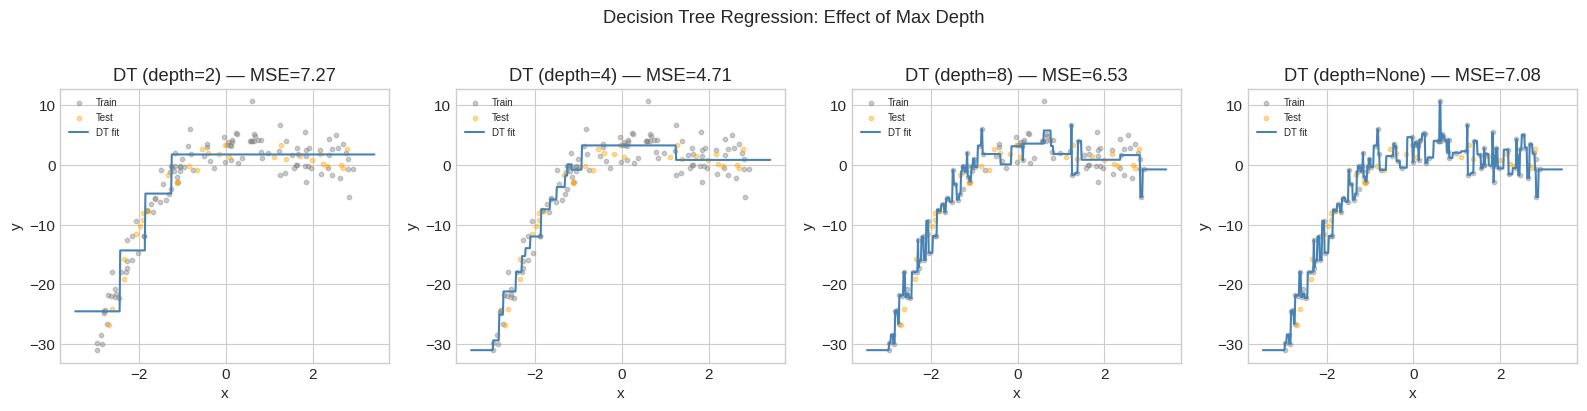

In [66]:
fig, axes = plt.subplots(1, len(depths), figsize=(16, 4))
x_grid = np.linspace(X_poly_1d.min() - 0.5, X_poly_1d.max() + 0.5, 500).reshape(-1, 1)

for ax, depth in zip(axes, depths):
    dt = dt_models[depth]
    y_grid = dt.predict(x_grid)

    ax.scatter(X_poly_train, y_poly_train, s=10, alpha=0.4, color="gray", label="Train")
    ax.scatter(X_poly_test, y_poly_test, s=10, alpha=0.4, color="orange", label="Test")
    ax.plot(x_grid, y_grid, color="steelblue", linewidth=1.5, label="DT fit")

    depth_str = str(depth) if depth else "None"
    test_err = mse(y_poly_test, dt.predict(X_poly_test_2d))
    ax.set_title(f"DT (depth={depth_str}) — MSE={test_err:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend(fontsize=7)

plt.suptitle("Decision Tree Regression: Effect of Max Depth", y=1.02)
plt.tight_layout()
plt.show()

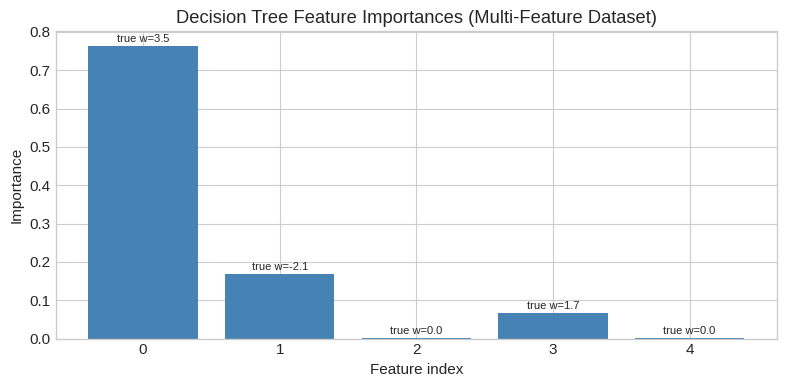

Decision Tree (depth=5) on Multi-Feature Dataset:
  Test                            MSE=3.763128  R²=0.791644


In [92]:
# Train decision tree on the multi-feature linear dataset
dt_multi = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_multi.fit(X_train_s, y_train)
y_pred_dt_multi_test = dt_multi.predict(X_test_s)

# Plot feature importances
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
importance = dt_multi.feature_importances_
ax.bar(range(model_dim), importance, color="steelblue")
ax.set_xlabel("Feature index")
ax.set_ylabel("Importance")
ax.set_title("Decision Tree Feature Importances (Multi-Feature Dataset)")

# Annotate true weights for reference
for i, (imp, tw) in enumerate(zip(importance, true_weights)):
    ax.annotate(f"true w={tw}", (i, imp + 0.01), ha="center", fontsize=8)
plt.tight_layout()
plt.show()

print("Decision Tree (depth=5) on Multi-Feature Dataset:")
print_metrics(y_test, y_pred_dt_multi_test, "Test")

---
# 8) Comparison

## 8.1 Model Predictions

In [68]:
# Collect all models and predictions on the multi-feature test set
results_multi = {}

# Linear (OLS)
results_multi["OLS"] = y_pred_ols_test

# Linear (GD)
results_multi["Linear GD"] = y_pred_gd_test

# Ridge
results_multi["Ridge (0.1)"] = y_pred_ridge_test

# Lasso
results_multi["Lasso (0.05)"] = y_pred_lasso_test

# ElasticNet
results_multi["ElasticNet"] = y_pred_en_test

# Decision Tree
results_multi["DT (d=5)"] = y_pred_dt_multi_test

# sklearn reference
results_multi["sklearn LR"] = y_pred_sk_test

print(f"{'Model':25s} {'MSE':>10s} {'R²':>10s}")
print("-" * 47)
for name, y_pred in results_multi.items():
    print(f"{name:25s} {mse(y_test, y_pred):10.6f} {r2(y_test, y_pred):10.6f}")

Model                            MSE         R²
-----------------------------------------------
OLS                         0.262841   0.981388
Linear GD                   0.262841   0.981388
Ridge (0.1)                 0.393981   0.972101
Lasso (0.05)                0.266912   0.981099
ElasticNet                  0.319601   0.977368
DT (d=5)                    3.853667   0.727114
sklearn LR                  0.262841   0.981388


In [69]:
# Compare all methods on the make_regression dataset (10 features, 5 informative)
print("=" * 60)
print("COMPARISON ON make_regression DATASET (10 features)")
print("=" * 60)

results_real = {}

# OLS
ols_r = LinearRegressionOLS().fit(X_real_train_s, y_real_train)
results_real["OLS (scratch)"] = ols_r.predict(X_real_test_s)

# GD
gd_r = LinearRegressionGD(lr=0.01, max_iter=5000).fit(X_real_train_s, y_real_train)
results_real["Linear GD"] = gd_r.predict(X_real_test_s)

# Ridge
ridge_r = RidgeRegressor(lam=1.0).fit(X_real_train_s, y_real_train)
results_real["Ridge (1.0)"] = ridge_r.predict(X_real_test_s)

# Lasso
lasso_r = LassoRegressor(lam=0.5, max_iter=5000).fit(X_real_train_s, y_real_train)
results_real["Lasso (0.5)"] = lasso_r.predict(X_real_test_s)

# ElasticNet
en_r = ElasticNetRegressor(alpha=0.5, l1_ratio=0.5, max_iter=5000).fit(X_real_train_s, y_real_train)
results_real["ElasticNet"] = en_r.predict(X_real_test_s)

# SVR (RBF)
svr_r = SVR(kernel="rbf", C=100.0, epsilon=1.0, gamma="scale")
svr_r.fit(X_real_train_s, y_real_train)
results_real["SVR (RBF)"] = svr_r.predict(X_real_test_s)

# Decision Tree
dt_r = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_real_train_s, y_real_train)
results_real["DT (d=5)"] = dt_r.predict(X_real_test_s)

print(f"\n{'Model':25s} {'MSE':>12s} {'R²':>10s}")
print("-" * 49)
for name, y_pred in results_real.items():
    print(f"{name:25s} {mse(y_real_test, y_pred):12.4f} {r2(y_real_test, y_pred):10.6f}")

COMPARISON ON make_regression DATASET (10 features)

Model                              MSE         R²
-------------------------------------------------
OLS (scratch)                 241.1079   0.988095
Linear GD                     241.1079   0.988095
Ridge (1.0)                  5087.4548   0.748797
Lasso (0.5)                   236.6527   0.988315
ElasticNet                   1012.4613   0.950008
SVR (RBF)                    2296.3151   0.886615
DT (d=5)                     6025.3731   0.702486


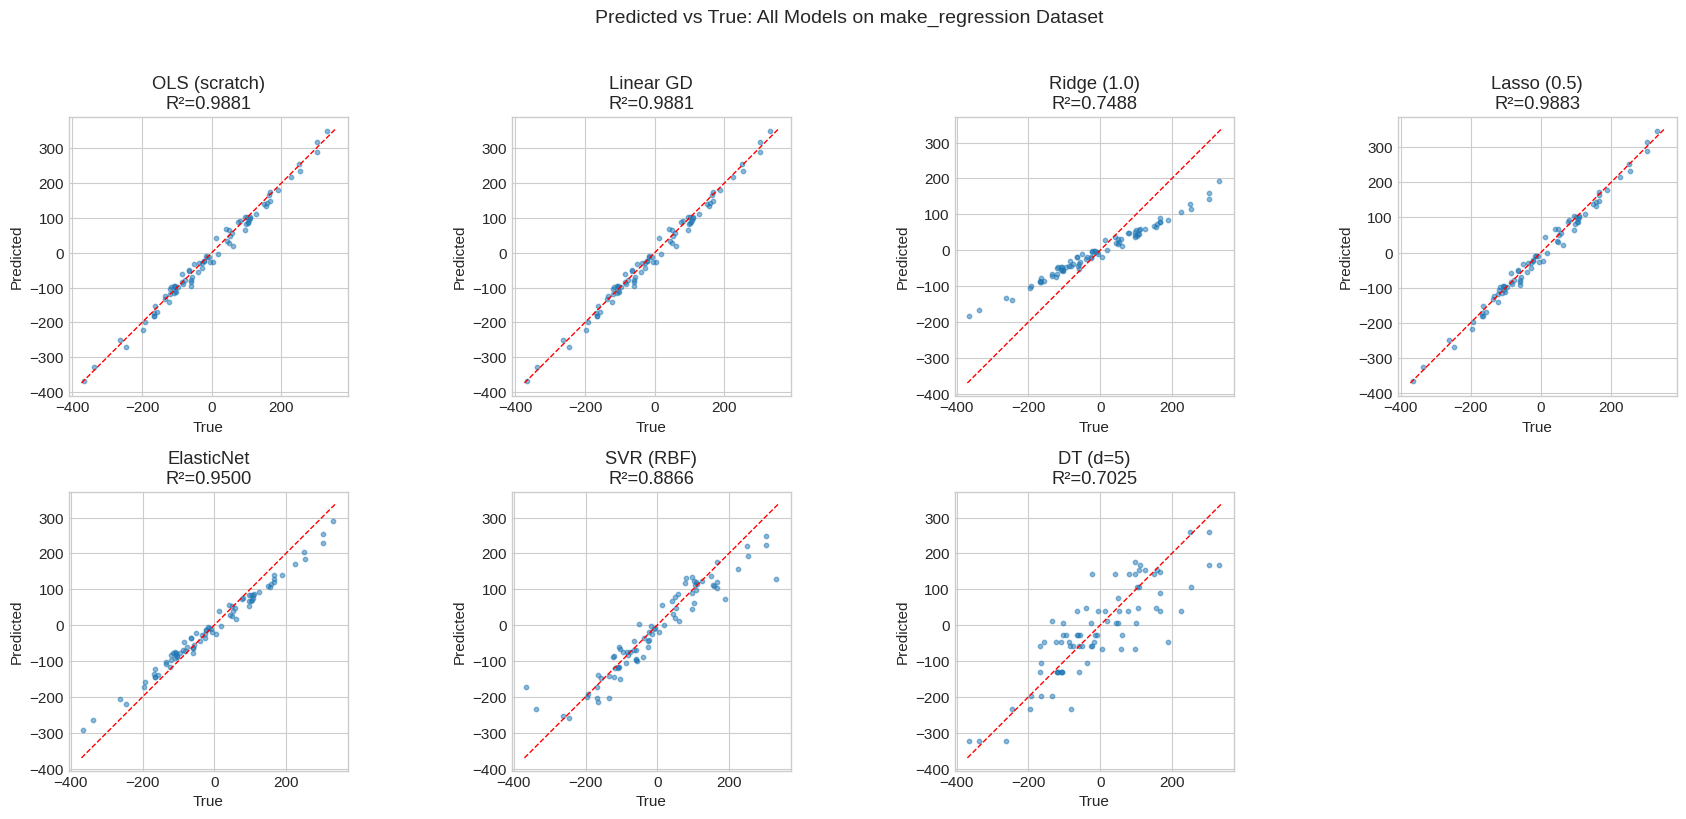

In [70]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, (name, y_pred) in enumerate(results_real.items()):
    if i >= len(axes):
        break
    ax = axes[i]
    ax.scatter(y_real_test, y_pred, s=10, alpha=0.5)
    lims = [min(y_real_test.min(), y_pred.min()) - 5, max(y_real_test.max(), y_pred.max()) + 5]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name}\nR²={r2(y_real_test, y_pred):.4f}")
    ax.set_aspect("equal")

# Hide unused subplot
if len(results_real) < len(axes):
    for j in range(len(results_real), len(axes)):
        axes[j].set_visible(False)

plt.suptitle("Predicted vs True: All Models on make_regression Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8.2 Summary Comparison Table

| Method | Type | Sparsity | Closed-Form | Key Hyperparameter | Best For |
|--------|------|----------|-------------|-------------------|----------|
| **OLS** | Linear | No | Yes | — | Baseline, well-conditioned problems |
| **Ridge** | Linear + L2 | No | Yes | $\lambda$ (reg. strength) | Multicollinearity, $p \approx n$ |
| **Lasso** | Linear + L1 | **Yes** | No | $\lambda$ (reg. strength) | Feature selection, sparse models |
| **ElasticNet** | Linear + L1 + L2 | Partial | No | $\alpha$, $r$ (l1_ratio) | Correlated features + sparsity |
| **Polynomial** | Nonlinear (feature expansion) | No | Yes | Degree $d$ | Known polynomial relationships |
| **SVR** | Nonlinear (kernel) | — | No | $C$, $\varepsilon$, kernel | Robust to outliers, nonlinear |
| **Decision Tree** | Nonlinear (partitioning) | — | N/A | `max_depth` | Complex interactions, interpretability |

### Key Takeaways

1. **Start simple:** OLS is the right first model. If it overfits, add regularization.
2. **Ridge vs Lasso:** Use Ridge when all features matter; Lasso when you suspect sparsity. ElasticNet when unsure.
3. **Polynomial regression** is powerful for 1-D or low-$p$ problems but scales poorly. Always pair with regularization for high degrees.
4. **SVR** shines with its epsilon-insensitive loss and kernel flexibility, but is computationally expensive for large $n$.
5. **Decision Trees** capture interactions automatically but overfit easily. They are rarely used alone — they are the building blocks for Random Forests and Gradient Boosting (covered in ensemble methods).

## 8.2 Residual Analysis

A good regression model should produce residuals that are approximately:
- **Zero-mean** (unbiased)
- **Homoscedastic** (constant variance across predictions)
- **Uncorrelated** with the predicted values

Patterned residuals indicate model misspecification.

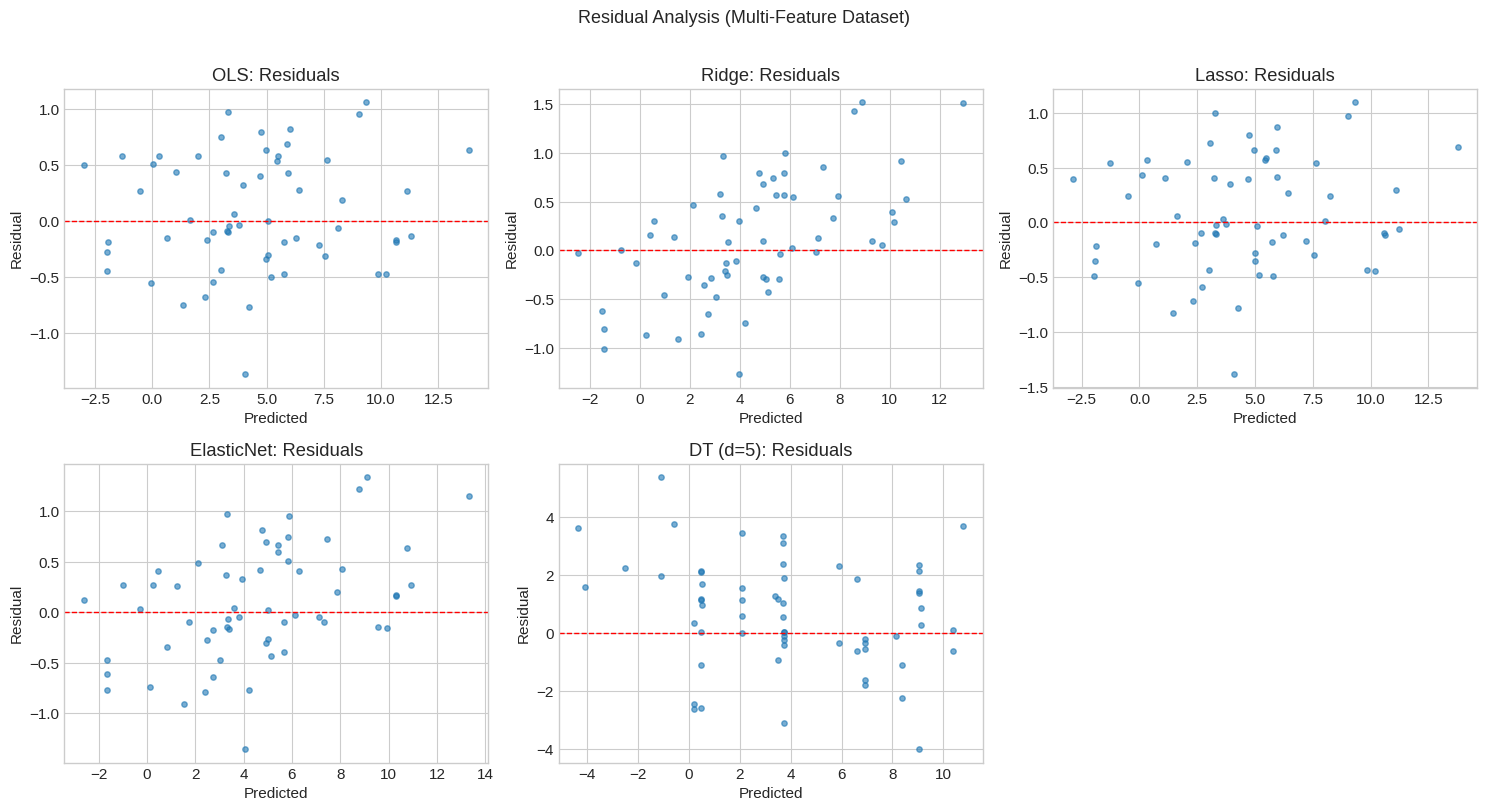

In [72]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

models_for_resid = {
    "OLS": results_multi["OLS"],
    "Ridge": results_multi["Ridge (0.1)"],
    "Lasso": results_multi["Lasso (0.05)"],
    "ElasticNet": results_multi["ElasticNet"],
    "DT (d=5)": results_multi["DT (d=5)"],
}

for ax, (name, y_pred) in zip(axes, models_for_resid.items()):
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, s=15, alpha=0.6)
    ax.axhline(y=0, color="red", linestyle="--", linewidth=1)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")
    ax.set_title(f"{name}: Residuals")

axes[-1].set_visible(False)
plt.suptitle("Residual Analysis (Multi-Feature Dataset)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

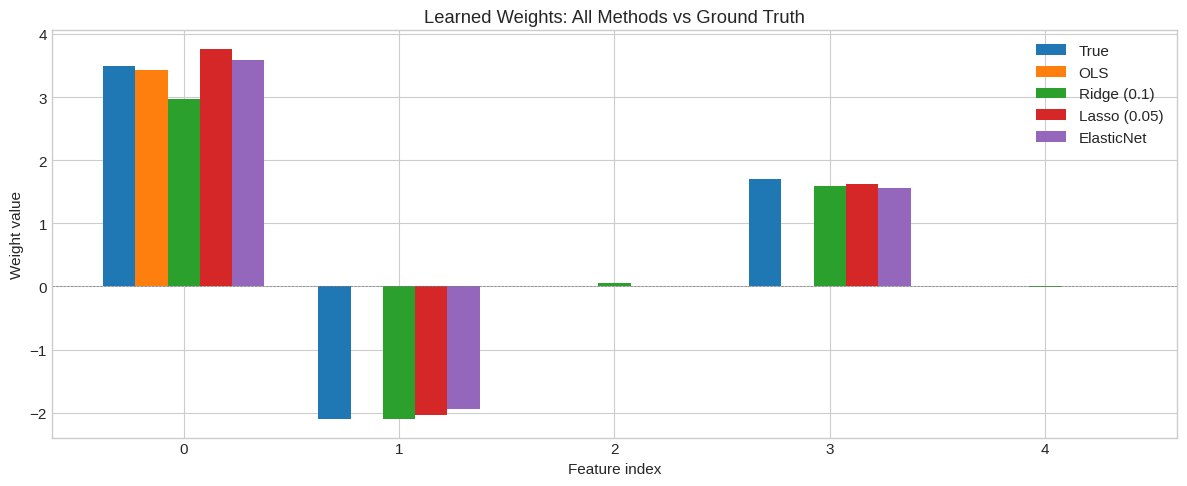

Method                 Non-zero weights  Weight L1 norm  Weight L2 norm
----------------------------------------------------------------------
True                                  3          7.3000          4.4215
OLS                                   1          3.4345          3.4345
Ridge (0.1)                           5          6.7208          3.9743
Lasso (0.05)                          3          7.4212          4.5760
ElasticNet                            4          7.0886          4.3698


In [93]:
# Prepare weights for comparison by padding OLS weights
ols_full_weights = np.zeros(model_dim)
ols_full_weights[0] = ols.weights[0]

methods_weights = {
    "True": true_weights,
    "OLS": ols_full_weights,
    "Ridge (0.1)": ridge.weights,
    "Lasso (0.05)": lasso.weights,
    "ElasticNet": en.weights,
}

# Plot final weight comparison across all from-scratch linear methods
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
x_pos = np.arange(model_dim)
width = 0.15

for i, (name, weights) in enumerate(methods_weights.items()):
    offset = (i - len(methods_weights) / 2 + 0.5) * width
    ax.bar(x_pos + offset, weights, width, label=name)

ax.set_xlabel("Feature index")
ax.set_ylabel("Weight value")
ax.set_title("Learned Weights: All Methods vs Ground Truth")
ax.legend()
ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# Print sparsity comparison
print(f"{'Method':20s} {'Non-zero weights':>18s} {'Weight L1 norm':>15s} {'Weight L2 norm':>15s}")
print("-" * 70)
for name, weights in methods_weights.items():
    nnz = np.sum(np.abs(weights) > 1e-4)
    l1 = np.sum(np.abs(weights))
    l2 = np.sqrt(np.sum(weights**2))
    print(f"{name:20s} {nnz:>18d} {l1:>15.4f} {l2:>15.4f}")